In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv("insurance.csv")

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.shape

(1338, 7)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
data.duplicated().sum()

1

In [9]:
data = data.drop_duplicates()

In [10]:
data.duplicated().sum()

0

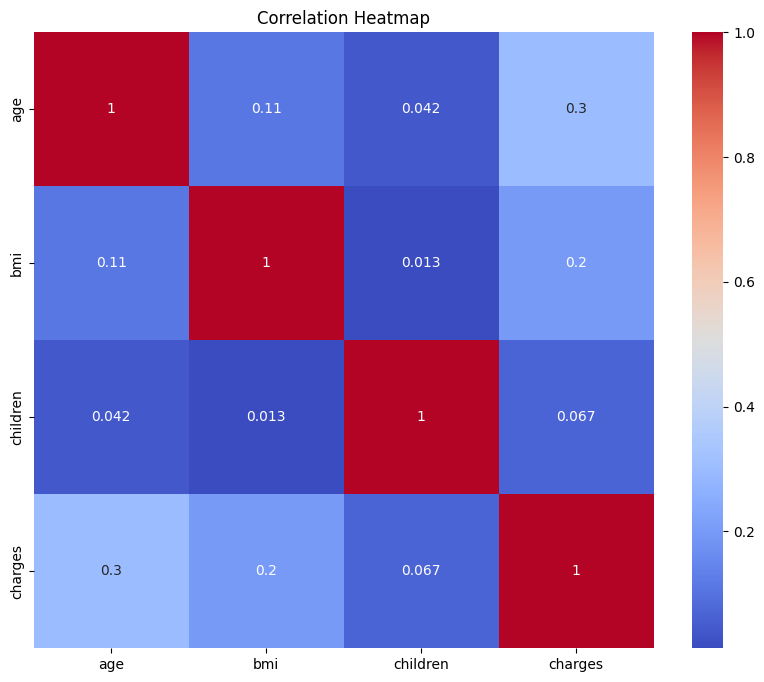

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

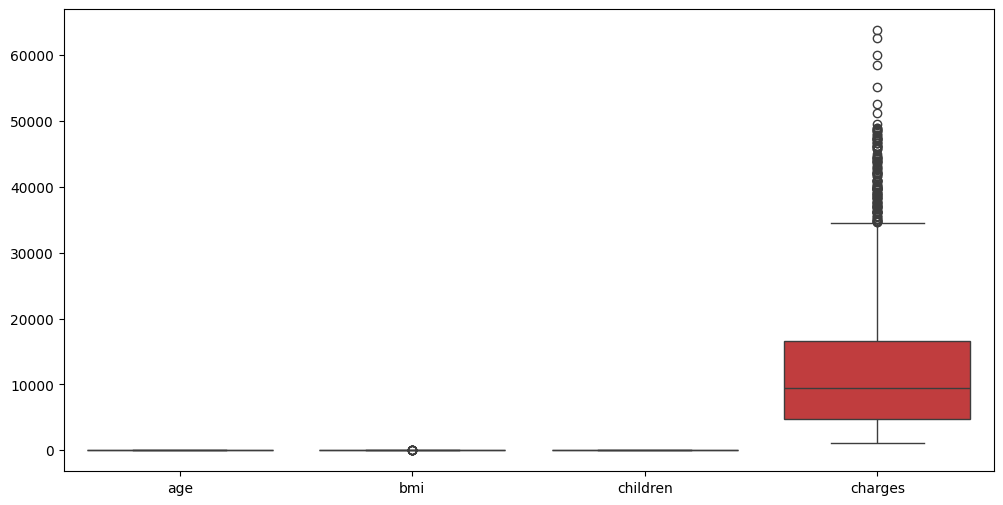

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(data=data.select_dtypes(include=np.number))

plt.show()

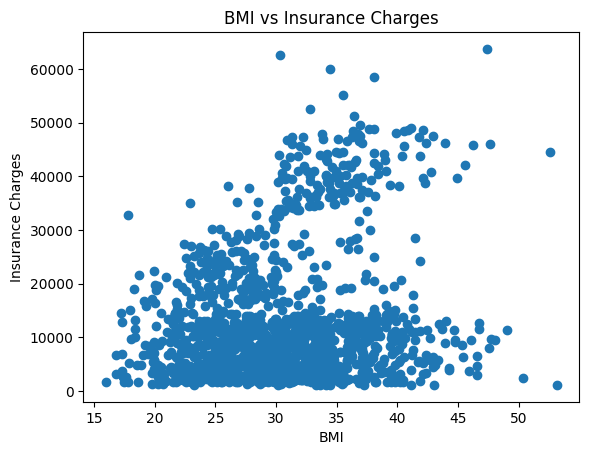

In [13]:
plt.scatter(data['bmi'], data['charges'])

plt.xlabel("BMI")

plt.ylabel("Insurance Charges")

plt.title("BMI vs Insurance Charges")

plt.show()

In [14]:
le = LabelEncoder()

data['sex'] = le.fit_transform(data['sex'])

data['smoker'] = le.fit_transform(data['smoker'])

data['region'] = le.fit_transform(data['region'])

In [15]:
X = data.drop('charges', axis=1)

y = data['charges']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
sc_X = StandardScaler()

sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)

X_test = sc_X.transform(X_test)

y_train = sc_y.fit_transform(y_train.values.reshape(-1,1))

In [18]:
model = SVR(kernel='rbf')

model.fit(X_train, y_train.ravel())

SVR()

In [19]:
y_pred = model.predict(X_test)

In [20]:
y_pred = sc_y.inverse_transform(y_pred.reshape(-1,1))

In [21]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Mean Squared Error: 21864976.070253946
R2 Score: 0.8810108597811305


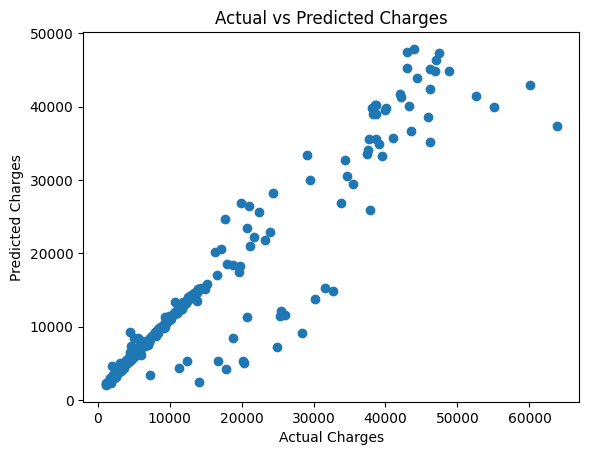

In [22]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()